## **Part 1 — Data Understanding & Exploration**

### **1.Import Libraries and Load**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/healthcare_dataset.csv")

# View first rows
df.head()

,patient_id,age,bmi,exercise_hours_per_week,smoker,blood_pressure,diabetes
0,1,31,18.3,1.5,0,119.1,0
1,2,44,26.3,3.1,0,120.5,0
2,3,43,24.2,4.8,0,130.3,0
3,4,32,25.0,6.0,0,119.5,0
4,5,28,22.1,4.2,1,127.4,0


### **2.Explore dataset**

In [3]:
# Shape
print("Shape:", df.shape)

# Data types
print(df.dtypes)

# Missing values
print(df.isnull().sum())

Shape: (6000, 7)
patient_id                   int64
age                          int64
bmi                        float64
exercise_hours_per_week    float64
smoker                       int64
blood_pressure             float64
diabetes                     int64
dtype: object
patient_id                 0
age                        0
bmi                        0
exercise_hours_per_week    0
smoker                     0
blood_pressure             0
diabetes                   0
dtype: int64


### **3.Basic Statistics**

In [4]:
df.describe()

,patient_id,age,bmi,exercise_hours_per_week,smoker,blood_pressure,diabetes
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,3000.500000,51.107333,25.995267,3.012800,0.307000,134.239733,0.090333
std,1732.195139,19.522722,4.960541,1.491802,0.461288,11.234260,0.286683
min,1.000000,18.000000,15.000000,0.000000,0.000000,94.000000,0.000000
25%,1500.750000,34.000000,22.500000,2.000000,0.000000,126.000000,0.000000
50%,3000.500000,51.000000,26.100000,3.000000,0.000000,134.200000,0.000000
75%,4500.250000,68.000000,29.400000,4.000000,1.000000,142.325000,0.000000
max,6000.000000,84.000000,44.900000,8.500000,1.000000,169.700000,1.000000


### **4.Visualizations**

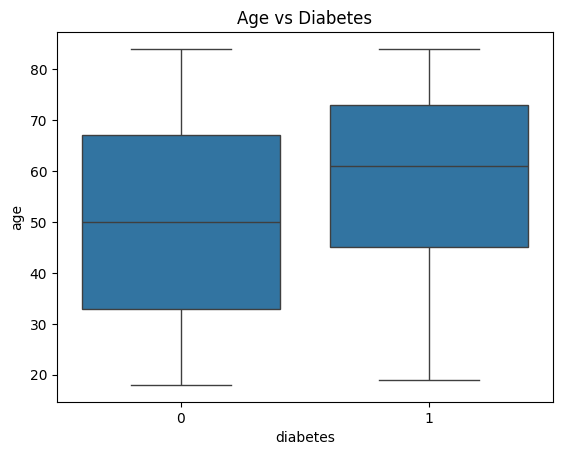

In [5]:
# age vs diabetics
sns.boxplot(x='diabetes', y='age', data=df)
plt.title("Age vs Diabetes")
plt.show()

#### insights from age vs diabetics


 - People with diabetes (1) have a higher median age (60)
 - People without diabetes (0) have a lower median age (50)
 - The diabetes group is more concentrated in older age ranges (45–75)
 - Older individuals are more likely to be diabetic compared to younger ones

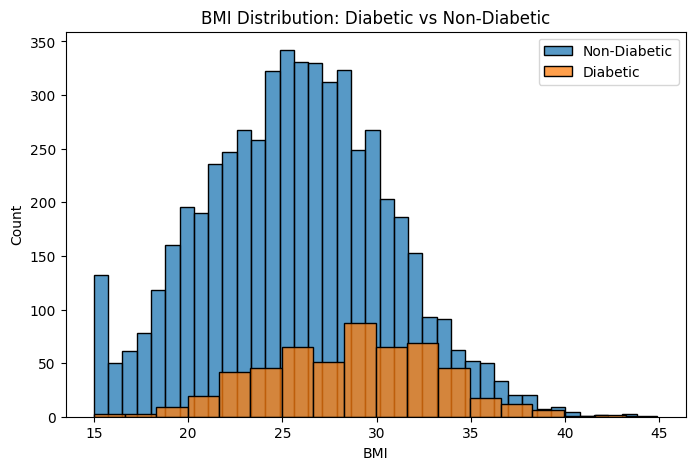

In [12]:
plt.figure(figsize=(8,5))

# Non-diabetic
sns.histplot(df[df['diabetes'] == 0]['bmi'], label='Non-Diabetic')

# Diabetic
sns.histplot(df[df['diabetes'] == 1]['bmi'], label='Diabetic')

plt.legend()
plt.title("BMI Distribution: Diabetic vs Non-Diabetic")
plt.xlabel("BMI")
plt.show()



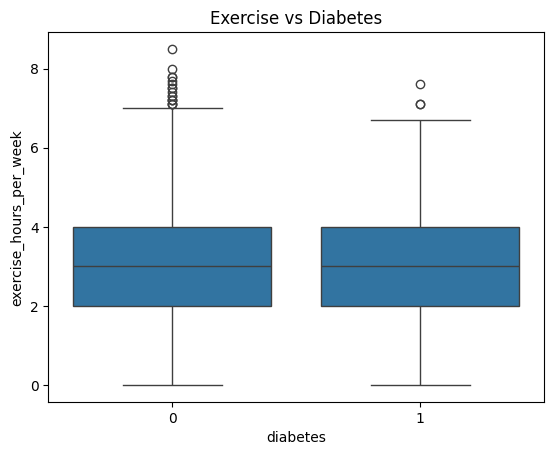

In [9]:
# exercise vs diabetics
sns.boxplot(x='diabetes', y='exercise_hours_per_week', data=df)
plt.title("Exercise vs Diabetes")
plt.show()

#### Insights from exercise vs diabetics
- Median exercise hours for both groups is almost similar (~3 hours/week)
- Non-diabetic group (0) has more high-exercise outliers (7–8+ hours)
- Diabetic group has slightly lower spread in higher exercise values

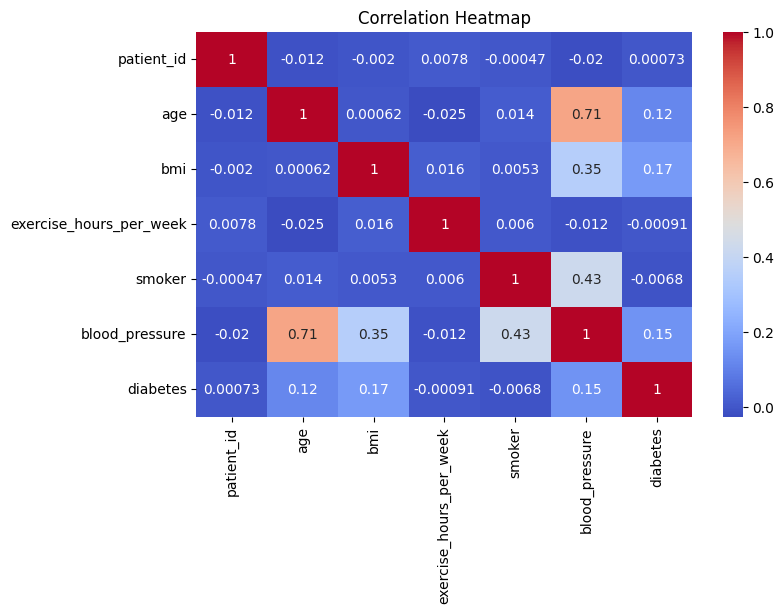

In [10]:
# correlation heatmapping
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#### Insights from correlation map
1. BMI has strongest link with diabetes

2. Blood pressure also matters

3. Age has some influence

4. Exercise shows almost less correlation

5. Smoker has weak relationship

## **Part 2 - Machine Learning Model (Logistic Regression)**

In [13]:
# features and target
X = df.drop(columns=['patient_id', 'diabetes'])
y = df['diabetes']

In [14]:
# train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

In [15]:
# feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
# train Logistic regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [19]:
# Prediction
y_pred = model.predict(X_test)

Accuracy: 0.9191666666666667


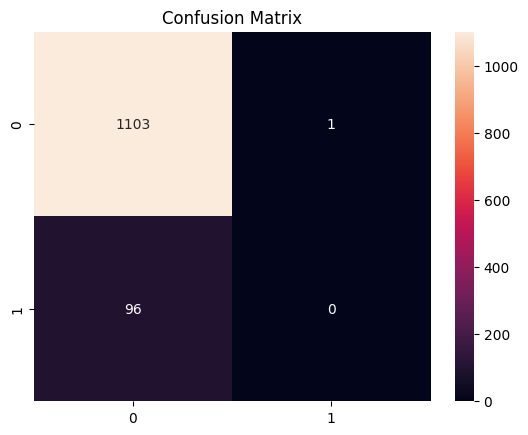

              precision    recall  f1-score   support

           0       0.92      1.00      0.96      1104
           1       0.00      0.00      0.00        96

    accuracy                           0.92      1200
   macro avg       0.46      0.50      0.48      1200
weighted avg       0.85      0.92      0.88      1200



In [21]:
# Evaluation metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred))


#### feature importance

In [22]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print(importance)

                   Feature  Coefficient
1                      bmi     0.531130
0                      age     0.283348
4           blood_pressure     0.242566
2  exercise_hours_per_week     0.004525
3                   smoker    -0.144773


- Positive coefficient → increases diabetes risk
- BMI, age and blood pressure are top predictors

## **Part 3 — Neural Network Model**

In [24]:
# import tenserflow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [32]:
# build model
model1 = Sequential()

# Input + Hidden layers
model1.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))
model1.add(Dense(8, activation='relu'))

# Output layer
model1.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
# Compile Model
model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [34]:
# train model
history = model1.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8701 - loss: 0.3808 - val_accuracy: 0.9010 - val_loss: 0.3166
Epoch 2/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9086 - loss: 0.2902 - val_accuracy: 0.9010 - val_loss: 0.3091
Epoch 3/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9086 - loss: 0.2868 - val_accuracy: 0.9010 - val_loss: 0.3048
Epoch 4/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9086 - loss: 0.2849 - val_accuracy: 0.9010 - val_loss: 0.3071
Epoch 5/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9086 - loss: 0.2847 - val_accuracy: 0.9010 - val_loss: 0.3029
Epoch 6/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9086 - loss: 0.2833 - val_accuracy: 0.9010 - val_loss: 0.3012
Epoch 7/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9086 - loss: 0.2831 - val_accuracy: 0.9010 - val_loss: 0.2989
Epoch 8/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9086 - loss: 0.2821 - val_accuracy: 0.

In [36]:
# Evaluate
loss, accuracy = model1.evaluate(X_test, y_test)
print("Neural Network Accuracy:", accuracy)

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9200 - loss: 0.2593
Neural Network Accuracy: 0.9200000166893005


## **Part 4 Model Comparison**

- Logistic Regression Accuracy : 91.91%
- Neural Network Accuracy : 92.00%



The Neural Network achieved slightly higher accuracy than Logistic Regression, but the difference is very small (only **0.09%**). This shows that both models perform well on this dataset.

### Strengths of Machine Learning Models (Logistic Regression)
- Faster training and requires less computational power  
- Highly interpretable, meaning we can understand how each feature affects the prediction  
- Works well when relationships between variables are mostly linear  

### Strengths of Neural Networks
- Can learn complex and non-linear relationships between features  
- Automatically captures interactions between variables  
- More flexible and scalable for larger datasets    

### Limitations of Both Approaches

**Logistic Regression**
- Assumes a linear relationship between variables  
- Cannot easily capture complex patterns in data  
- Performance may decrease with more complex datasets  

**Neural Networks**
- Harder to interpret (acts like a "black box")  
- Requires more computational resources and training time  
- Needs larger datasets to perform optimally  

### Why Neural Networks May Perform Better
Neural Networks can model **non-linear patterns and complex interactions** between variables. In healthcare data, many factors such as age, lifestyle, and medical indicators interact together, and neural networks can capture these relationships better than simpler models.

### When Logistic Regression Might Be Preferable
Logistic Regression may be preferred when:
- Model **interpretability is important** (e.g., medical decision-making)
- The **dataset is small**
- Faster training and **simpler models** are required
- The relationship between variables is mostly **linear**

**Overall, both models performed similarly, but the Neural Network achieved slightly higher accuracy, indicating a small improvement in prediction capability.**